In [10]:
import numpy as np
import os
import json
from zipfile import ZipFile
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import layers, models

In [1]:
import os
import numpy as np
from glob import glob
from keras.preprocessing import image
from sklearn.model_selection import train_test_split

input_dir = "/home/gourib/LIDC-IDRI-slices"
img_shape = (128,128)  # Adjust according to your requirement
Thres = 100  # Threshold for segmentation mask

images = []
masks = []
y = []

# Step 1: Get all patient IDs
patients = sorted(os.listdir(input_dir))

# Step 2: Split patients into train and test sets
train_patients, test_patients = train_test_split(patients, train_size=0.8, random_state=25)

def load_patient_data(patient_list):
    """Load images and masks for the given list of patients"""
    images, masks, labels = [], [], []
    
    for patient in patient_list:
        patient_path = os.path.join(input_dir, patient)
        
        for nodule in os.listdir(patient_path):
            mask0, mask1, mask2, mask3 = [], [], [], []

            # Load images
            for filename in glob(f"{patient_path}/{nodule}/images/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                images.append(np.asarray(img))

            # Load masks
            for filename in glob(f"{patient_path}/{nodule}/mask-0/*.png"):
                img = image.load_img(filename, target_size=img_shape)
                mask1.append(np.asarray(img))

            # Determine final mask selection
            for i in range(len(mask1)):
                white_sum = mask1[i].sum()
                label = 1 if white_sum > Thres else 0
                
                labels.append(label)
                masks.append(mask1[i])
    
    return images, masks, labels

# Step 3: Load training and testing data based on patient-wise split
x_train, mask_train, y_train = load_patient_data(train_patients)
x_test, mask_test, y_test = load_patient_data(test_patients)

# Convert to NumPy arrays
x_train, x_test = np.array(x_train)/255, np.array(x_test)/255
mask_train, mask_test = np.array(mask_train)/255, np.array(mask_test)/255
y_train, y_test = np.array(y_train), np.array(y_test)

# Print shapes
print(x_train.shape, x_test.shape)
print(mask_train.shape, mask_test.shape)

2025-03-10 10:58:42.829332: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-10 10:58:42.926405: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-10 10:58:42.955099: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-10 10:58:42.963386: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-10 10:58:43.056697: I tensorflow/core/platform/cpu_feature_guar

(12376, 128, 128, 3) (3172, 128, 128, 3)
(12376, 128, 128, 3) (3172, 128, 128, 3)


In [2]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential,load_model
from keras import layers
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization,Embedding,TimeDistributed
from keras.layers import Conv2D, MaxPooling2D, ReLU, LSTM,Bidirectional,Attention,Concatenate,concatenate
from keras import regularizers, optimizers,losses
from keras.layers import DepthwiseConv2D,Add, ReLU, GlobalAveragePooling2D, GlobalMaxPooling2D,MultiHeadAttention
from keras.layers import Activation,ActivityRegularization, AvgPool2D, LeakyReLU, Conv2DTranspose
from keras.metrics import Accuracy,Recall,Precision,AUC,TruePositives,TrueNegatives,FalseNegatives,FalsePositives, SpecificityAtSensitivity,SensitivityAtSpecificity
from keras.utils import plot_model
from keras.preprocessing import image
from keras.utils import to_categorical
import numpy as np
import matplotlib
import sklearn
import matplotlib.pyplot as plt
import time
import os
import sklearn.metrics as m
from glob import glob
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [3]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.layers import (Conv2D, Conv2DTranspose, Dropout, BatchNormalization, concatenate, Input)
from keras.models import Model

Name = "MobileNetV2_U-NetPP"

def conv_block(inputs, num_filters, dropout_rate=0.3):
    x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = Conv2D(num_filters, (3, 3), activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    return x

def mobilenet_unetpp():
    img_shape = (128, 128, 3)
    mobilenet = MobileNetV2(include_top=False, weights="imagenet", input_shape=img_shape)
    
    for layer in mobilenet.layers:
        layer.trainable = False

    # Encoder (MobileNetV2 features)
    c1 = mobilenet.get_layer("block_1_expand_relu").output  # 64x64
    c2 = mobilenet.get_layer("block_3_expand_relu").output  # 32x32
    c3 = mobilenet.get_layer("block_6_expand_relu").output  # 16x16
    c4 = mobilenet.get_layer("block_13_expand_relu").output # 8x8
    c5 = mobilenet.get_layer("block_16_project").output     # 4x4 (Bottleneck)

    # Nested Decoder (UNet++)
    d4_1 = conv_block(c4, 256)
    d3_1 = conv_block(c3, 128)
    d3_2 = conv_block(concatenate([d3_1, Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(d4_1)]), 128)
    d2_1 = conv_block(c2, 64)
    d2_2 = conv_block(concatenate([d2_1, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_1)]), 64)
    d2_3 = conv_block(concatenate([d2_1, d2_2, Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(d3_2)]), 64)
    d1_1 = conv_block(c1, 32)
    d1_2 = conv_block(concatenate([d1_1, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_1)]), 32)
    d1_3 = conv_block(concatenate([d1_1, d1_2, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_2)]), 32)
    d1_4 = conv_block(concatenate([d1_1, d1_2, d1_3, Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(d2_3)]), 32)
    
    # Final upsampling and output
    u0_1 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding="same")(d1_4)
    c0_1 = conv_block(u0_1, 16, dropout_rate=0.2)
    outputs = Conv2D(3, (1, 1), activation="sigmoid")(c0_1)
    
    model = Model(inputs=mobilenet.input, outputs=outputs, name="MobileNetV2_UNetPlusPlus")
    return model

# Create the model
unetpp_model = mobilenet_unetpp()
unetpp_model.summary()


2025-03-10 10:59:03.750906: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0


Model: "MobileNetV2_UNetPlusPlus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 4,106,243 (15.66 MB)

 Trainable params: 3,486,595 (13.30 MB)

 Non-trainable params: 619,648 (2.36 MB)

In [4]:
def dice_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# IoU (Jaccard Index)
def iou_coef(y_true, y_pred, smooth=1e-6):
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection
        return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

# Model Compilation
model= mobilenet_unetpp()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
        loss=dice_loss, 
        metrics=[dice_coef, iou_coef, tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])
#model.summary()


In [5]:
from keras.callbacks import ModelCheckpoint, EarlyStopping
checkpointer = ModelCheckpoint(Name + '_checkpoint.weights.h5', verbose=1, save_best_only=True, save_weights_only=True)


In [6]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_dice_coeff', 
    patience=5, 
    verbose=1, 
    restore_best_weights=True, 
    mode='max'  # Ensuring early stopping is based on maximizing dice coefficient
)


In [7]:


results = model.fit(
    x_train, mask_train, 
    validation_split=0.2, 
    batch_size=32, 
    epochs=300, 
    callbacks=[early_stopping]
)

Epoch 1/300


I0000 00:00:1741584573.956445  777664 service.cc:146] XLA service 0x79faa4004d90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1741584573.956485  777664 service.cc:154]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-03-10 10:59:34.578971: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-03-10 10:59:36.662883: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90201
2025-03-10 11:00:07.089915: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_transpose_fusion_1', 8 bytes spill stores, 120 bytes spill loads



  3/310 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - dice_coef: 0.0153 - iou_coef: 0.0077 - loss: 0.9846 - precision: 0.0078 - recall: 0.5109  

I0000 00:00:1741584607.390651  777664 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - dice_coef: 0.4017 - iou_coef: 0.2947 - loss: 0.5983 - precision: 0.1021 - recall: 0.7744

2025-03-10 11:00:53.649777: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_119', 4 bytes spill stores, 4 bytes spill loads



310/310 ━━━━━━━━━━━━━━━━━━━━ 104s 182ms/step - dice_coef: 0.4030 - iou_coef: 0.2958 - loss: 0.5970 - precision: 0.1026 - recall: 0.7741 - val_dice_coef: 0.4754 - val_iou_coef: 0.3234 - val_loss: 0.5250 - val_precision: 0.3709 - val_recall: 0.9267
Epoch 2/300
  1/310 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step - dice_coef: 0.7451 - iou_coef: 0.5937 - loss: 0.2549 - precision: 0.6690 - recall: 0.8409

/home/gourib/mnt/sdb/conds_envs/newk/lib/python3.9/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_dice_coeff` which is not available. Available metrics are: dice_coef,iou_coef,loss,precision,recall,val_dice_coef,val_iou_coef,val_loss,val_precision,val_recall
  current = self.get_monitor_value(logs)


310/310 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - dice_coef: 0.7501 - iou_coef: 0.6034 - loss: 0.2499 - precision: 0.7589 - recall: 0.7532 - val_dice_coef: 0.6480 - val_iou_coef: 0.5010 - val_loss: 0.3517 - val_precision: 0.8443 - val_recall: 0.5613
Epoch 3/300
310/310 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - dice_coef: 0.7673 - iou_coef: 0.6253 - loss: 0.2327 - precision: 0.7881 - recall: 0.7573 - val_dice_coef: 0.6119 - val_iou_coef: 0.4555 - val_loss: 0.3869 - val_precision: 0.5183 - val_recall: 0.8818
Epoch 4/300
310/310 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - dice_coef: 0.7781 - iou_coef: 0.6400 - loss: 0.2219 - precision: 0.7928 - recall: 0.7776 - val_dice_coef: 0.6974 - val_iou_coef: 0.5473 - val_loss: 0.3028 - val_precision: 0.6605 - val_recall: 0.8351
Epoch 5/300
310/310 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - dice_coef: 0.7926 - iou_coef: 0.6591 - loss: 0.2074 - precision: 0.8017 - recall: 0.7939 - val_dice_coef: 0.7057 - val_iou_coef: 0.5585 - val_loss: 0.2948 - val_precision: 0.7447 - val

In [8]:
test_results = model.evaluate(x_test, mask_test, batch_size=32)
print("Test Metrics:", test_results)
predictions = model.predict(x_test)

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - dice_coef: 0.7516 - iou_coef: 0.6181 - loss: 0.2484 - precision: 0.8159 - recall: 0.7438


2025-03-10 12:36:02.397214: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_reduce_transpose_fusion_1', 8 bytes spill stores, 16 bytes spill loads



Test Metrics: [0.24951376020908356, 0.7508718371391296, 0.6205174922943115, 0.7404594421386719, 0.8081968426704407]
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step


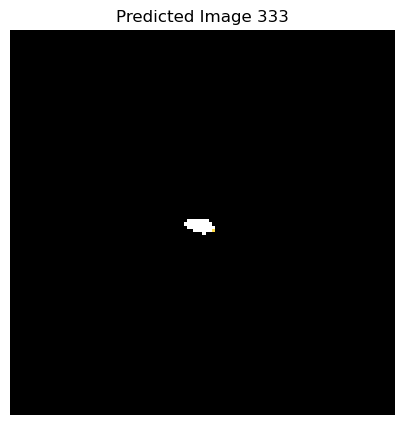

In [39]:
i = np.random.randint(len(mask_test))
# Display the selected ground truth and predicted mask
plt.figure(figsize=(5, 5))
plt.imshow(predictions[i], cmap='gray')  # Change to `mask_train[i]` to see the ground truth
plt.title(f"Predicted Image {i}")
plt.axis("off")
plt.show()

In [ ]:
model.save("finalseg.keras")  # Saves in the new Keras format


: 